Example 3.4.2
------------------------------
h(k)       = [-0.5+0.j    1. +0.25j -0. -0.5j ]
h index    = [-1  0  1]
q(k)       = [ 0. -0.16j -0.4+0.4j   1. +0.j   -0.4-0.4j   0. +0.16j]
q index    = [-2 -1  0  1  2]

h_norm_squared           = 1.5625
h_norm                   = 1.25
w0                       = 1.9607843137254908
gamma_inverse            = 2.4509803921568634
noise_gain               = 1.5686274509803926
zfe_loss_db              = 3.893398369101202
finite_center_error      = 2.2207880373005954e-16
finite_max_offcenter     = 9.813077866773594e-17


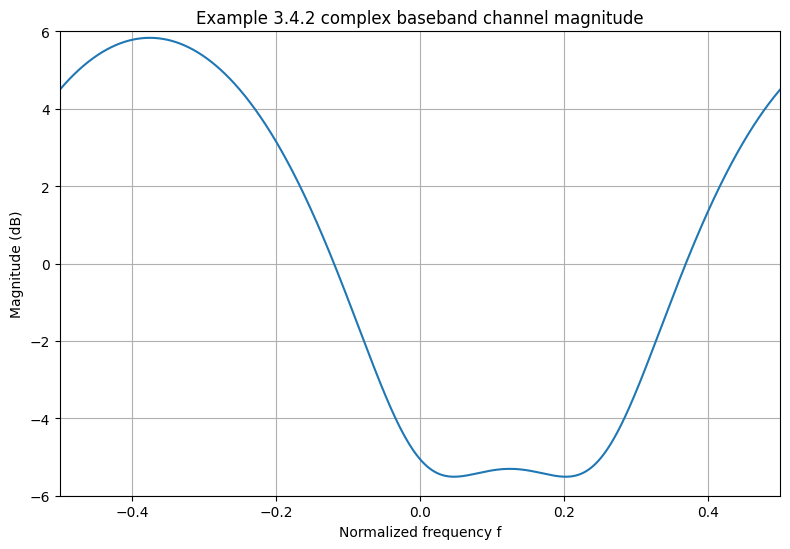

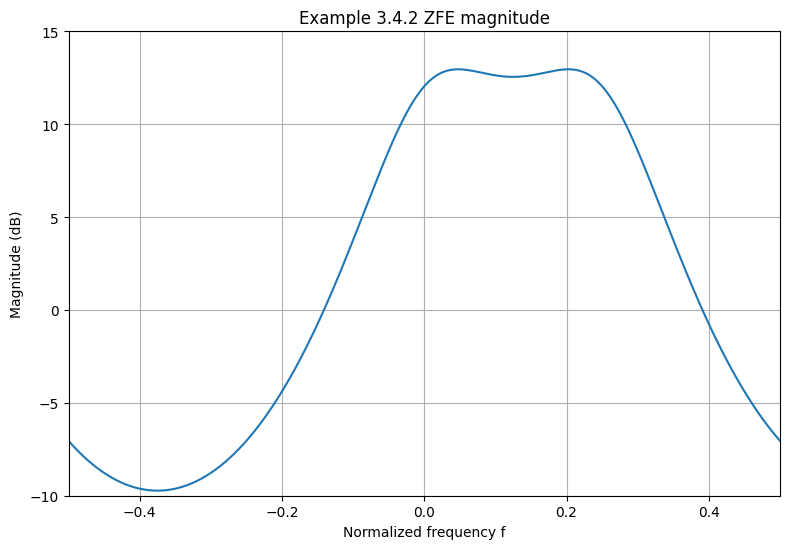

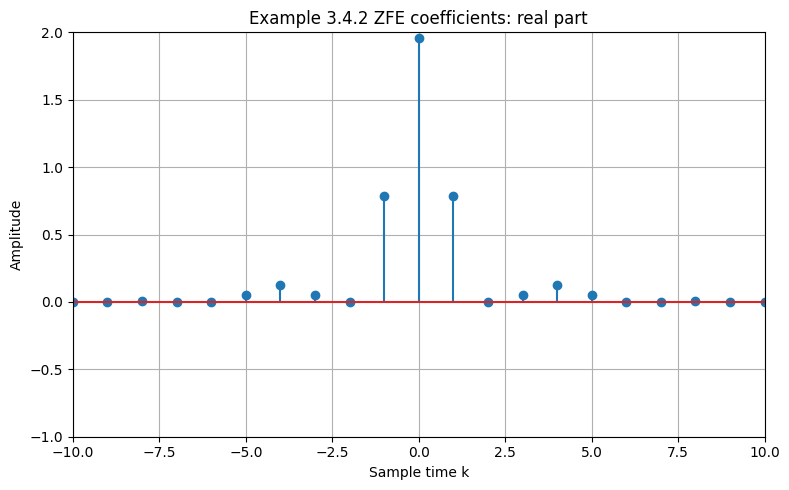

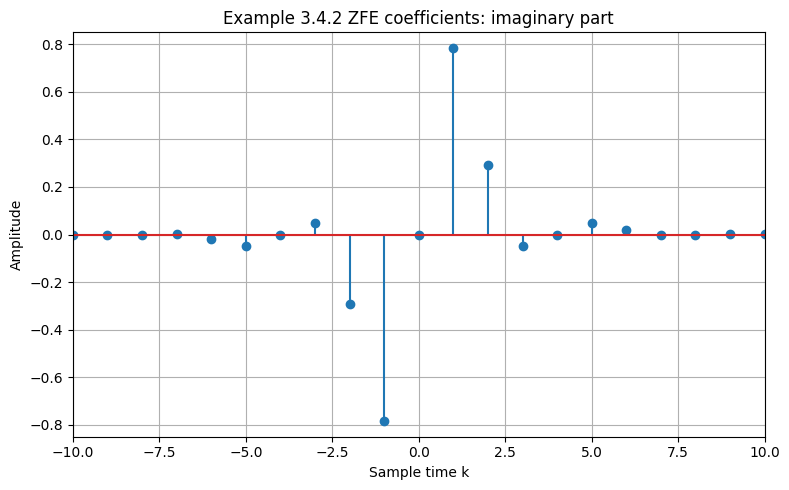

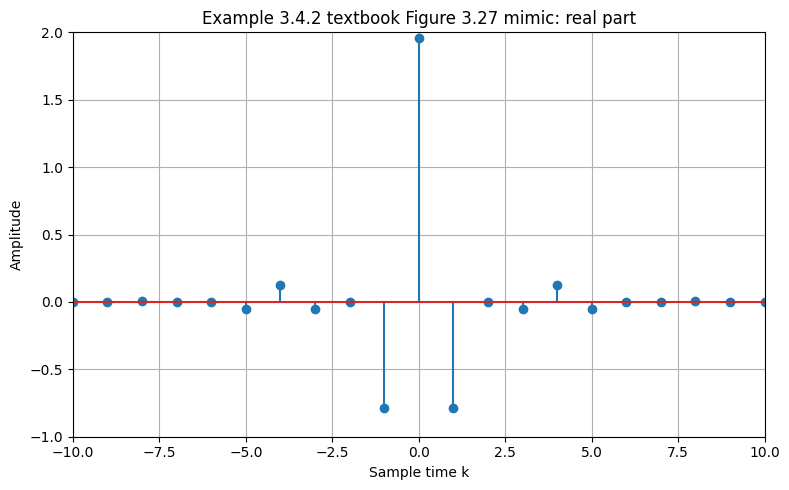

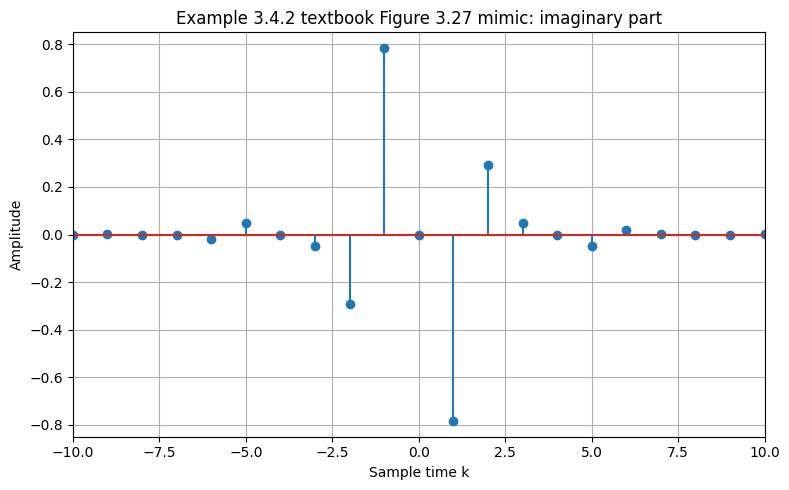

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from adsp import adspequalizer

Array = np.ndarray


def _db20(x: Array, floor_db: float = -300.0) -> Array:
  mag = np.maximum(np.abs(x), 10.0 ** (floor_db / 20.0))
  return 20.0 * np.log10(mag)


def _plotStem(
  tap_index: Array,
  tap_values: Array,
  title: str,
  ylim: tuple[float, float],
) -> None:
  fig = plt.figure(figsize=(8.0, 5.0))
  ax = fig.add_subplot(111)

  ax.stem(tap_index, tap_values)

  ax.set_xlim(-10, 10)
  ax.set_ylim(*ylim)
  ax.set_xlabel("Sample time k")
  ax.set_ylabel("Amplitude")
  ax.set_title(title)
  ax.grid(True)

  fig.tight_layout()


def runExample342() -> dict[str, float]:
  """
  Reproduce Chapter 3 Example 3.4.2 and validate adspequalizer.ZFE.

  Textbook complex-baseband channel:

    H(D) = -0.5 D^-1 + (1 + 0.25j) - 0.5j D

  with

    h[-1] = -0.5
    h[ 0] = 1 + 0.25j
    h[ 1] = -0.5j

  The Chapter 3 convention is

    D = exp(-j * 2*pi*f)

  and the ideal ZFE satisfies

    ||h|| W(D) Q(D) = 1.

  The textbook Figure 3.27 appears with an alternating (-1)^k factor
  relative to the direct inverse-DTFT coefficient convention.  Both the
  mathematically direct ZFE coefficients and the textbook-mimic
  coefficients are plotted below.
  """

  # --------------------------------------------------------------------------
  # Example 3.4.2 channel
  # --------------------------------------------------------------------------
  h = np.array([
    -0.5,
    1.0 + 0.25j,
    -0.5j,
  ], dtype=np.complex128)

  h_index = np.array([-1, 0, 1], dtype=int)

  # IMPORTANT:
  # Do not write
  #
  #   adspequalizer.ZFE = adspequalizer.ZFE.fromChannel(...)
  #
  # because that overwrites the ZFE class in the module.
  zfe = adspequalizer.ZFE.fromChannel(
    h,
    n_taps=129,
    n_fft=131072,
  )

  # --------------------------------------------------------------------------
  # Frequency axis:
  #
  #   f in [-0.5, 0.5] cycles/sample
  #
  # and
  #
  #   Omega = 2*pi*f
  # --------------------------------------------------------------------------
  frequency = np.linspace(-0.5, 0.5, 2001)
  omega = 2.0 * np.pi * frequency

  # --------------------------------------------------------------------------
  # Figure 3.25:
  # Complex baseband channel frequency response H(D)
  # --------------------------------------------------------------------------
  h_response = adspequalizer.BaseEqualizer.responseFromTaps(
    h,
    h_index,
    frequency,
  )

  fig = plt.figure(figsize=(8.0, 5.6))
  ax = fig.add_subplot(111)

  ax.plot(frequency, _db20(h_response))

  ax.set_xlim(-0.5, 0.5)
  ax.set_ylim(-6.0, 6.0)
  ax.set_xlabel("Normalized frequency f")
  ax.set_ylabel("Magnitude (dB)")
  ax.set_title("Example 3.4.2 complex baseband channel magnitude")
  ax.grid(True)

  fig.tight_layout()

  # --------------------------------------------------------------------------
  # Figure 3.26:
  #
  #   W_ZFE(D) = 1 / (||h|| Q(D))
  # --------------------------------------------------------------------------
  q_response = zfe.qResponse(omega)

  w_response = 1.0 / (
    zfe.h_norm * q_response
  )

  fig = plt.figure(figsize=(8.0, 5.6))
  ax = fig.add_subplot(111)

  ax.plot(frequency, _db20(w_response))

  ax.set_xlim(-0.5, 0.5)
  ax.set_ylim(-10.0, 15.0)
  ax.set_xlabel("Normalized frequency f")
  ax.set_ylabel("Magnitude (dB)")
  ax.set_title("Example 3.4.2 ZFE magnitude")
  ax.grid(True)

  fig.tight_layout()

  # --------------------------------------------------------------------------
  # Figure 3.27:
  # Ideal two-sided ZFE impulse response.
  #
  # Plot only -10 <= k <= 10 to match the textbook figure.
  # --------------------------------------------------------------------------
  tap_mask = (
    (zfe.w_index >= -10)
    & (zfe.w_index <= 10)
  )

  tap_index = zfe.w_index[tap_mask]
  tap_values = zfe.w[tap_mask]

  _plotStem(
    tap_index,
    np.real(tap_values),
    "Example 3.4.2 ZFE coefficients: real part",
    (-1.0, 2.0),
  )

  _plotStem(
    tap_index,
    np.imag(tap_values),
    "Example 3.4.2 ZFE coefficients: imaginary part",
    (-0.85, 0.85),
  )

  # --------------------------------------------------------------------------
  # Textbook Figure 3.27 mimic
  #
  # The supplied textbook plot corresponds to an alternating sign relative
  # to the direct D = exp(-j*Omega) inverse-DTFT coefficient convention:
  #
  #   w_textbook[k] = (-1)^k w[k]
  #
  # Keep this transformation in the example only.  Do NOT modify zfe.w,
  # because zfe.w is defined such that
  #
  #   ||h|| W(D) Q(D) = 1.
  # --------------------------------------------------------------------------
  textbook_taps = (
    (-1.0) ** tap_index
  ) * tap_values

  _plotStem(
    tap_index,
    np.real(textbook_taps),
    "Example 3.4.2 textbook Figure 3.27 mimic: real part",
    (-1.0, 2.0),
  )

  _plotStem(
    tap_index,
    np.imag(textbook_taps),
    "Example 3.4.2 textbook Figure 3.27 mimic: imaginary part",
    (-0.85, 0.85),
  )

  # --------------------------------------------------------------------------
  # Numerical validation
  # --------------------------------------------------------------------------
  residual = zfe.residualIsi()

  metrics = {
    "h_norm_squared": zfe.h_norm**2,
    "h_norm": zfe.h_norm,
    "w0": zfe.idealCenterTap(),
    "gamma_inverse": zfe.gammaInverse(),
    "noise_gain": zfe.outputNoiseGain(),
    "zfe_loss_db": zfe.lossDb(),
    "finite_center_error": residual["center_error"],
    "finite_max_offcenter": residual["max_offcenter"],
  }

  print("Example 3.4.2")
  print("------------------------------")
  print("h(k)       =", h)
  print("h index    =", h_index)
  print("q(k)       =", zfe.q)
  print("q index    =", zfe.q_index)
  print()

  for name, value in metrics.items():
    print(f"{name:24s} = {value}")

  # Show all figures only after they have all been created.
  plt.show()

  return metrics


if __name__ == "__main__":
  runExample342()

=== Ch.3 Example 3.5.2: QAM channel ===
h[k] (common 1/sqrt(T) omitted): [-0.5+0.j    1. +0.25j -0. -0.5j ]
||h||^2 = 1.56250000; ||h|| = 1.25000000
E_x = 1; MFB = 10 dB = 10 linear
N0/2 = E_x ||h||^2 / MFB = 0.15625000
q[-2] = +0.00000000-0.16000000j
q[-1] = -0.40000000+0.40000000j
q[+0] = +1.00000000+0.00000000j
q[+1] = -0.40000000-0.40000000j
q[+2] = +0.00000000+0.16000000j
Q(omega) min/max = 0.18000000 / 2.45137085

=== ZFE: regularization = 0.00000000 ===
P(D) coefficients for descending [D^4, D^3, D^2, D^1, D^0]:
[ 0.    +0.25j  -0.625 -0.625j  1.5625+0.j    -0.625 +0.625j
  0.    -0.25j ]
D-poles and residues (p_z = 1 / p_D):
  p_D=-0.00000000-2.00000000j, |p_D|=2.00000000, p_z=-0.00000000+0.50000000j, residue=+1.17647059+1.96078431j
  p_D=+2.00000000+0.00000000j, |p_D|=2.00000000, p_z=+0.50000000-0.00000000j, residue=-1.96078431-1.17647059j
  p_D=-0.00000000-0.50000000j, |p_D|=0.50000000, p_z=-0.00000000+2.00000000j, residue=+0.29411765-0.49019608j
  p_D=+0.50000000-0.00000000j

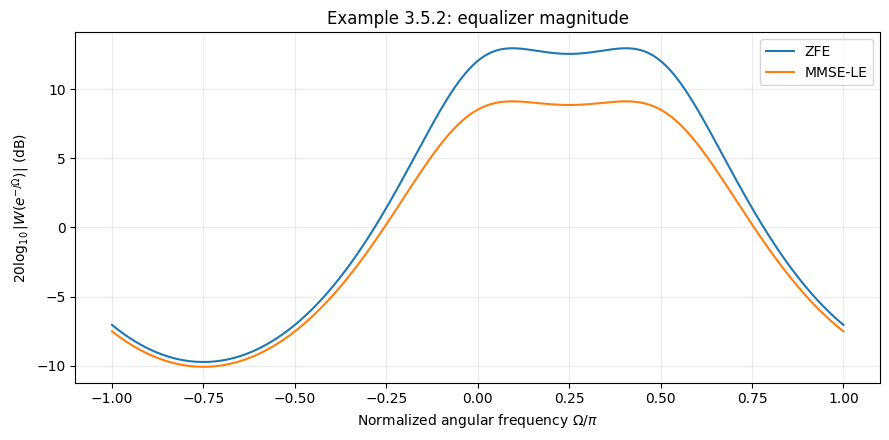

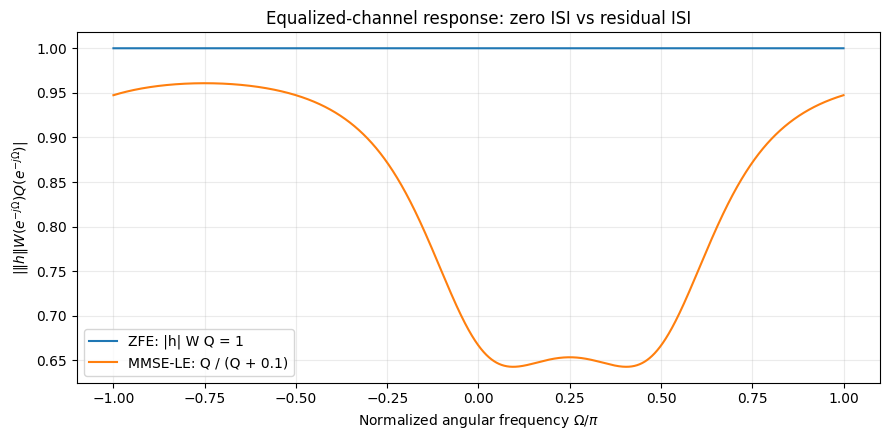

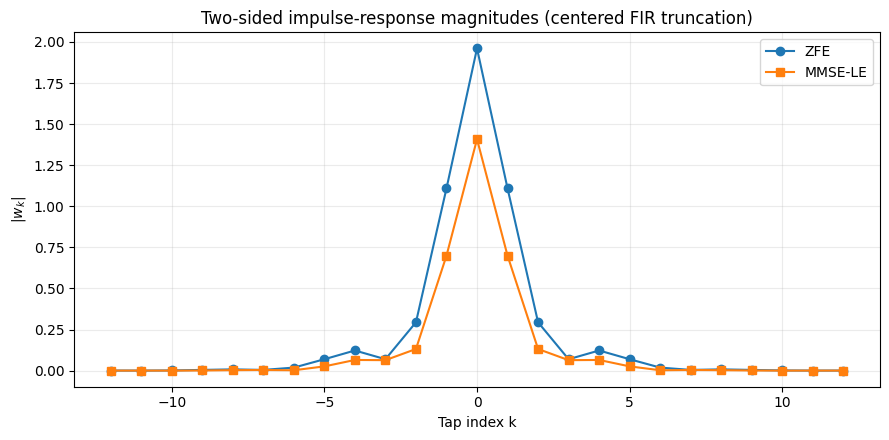


All numerical identities passed.


In [4]:
import argparse
from pathlib import Path

def polynomialAndResidues(h: np.ndarray, q: np.ndarray, reg: float):
  """W(D) = ||h|| D^2 / P(D), where P(D) has descending D powers 4,...,0.

  For each simple pole p of P, Res[W,p] = ||h|| p^2 / P'(p).
  The stable two-sided ROC retains only |p|>1 terms for w[0].
  """
  energy = float(np.vdot(h, h).real)
  poly = energy * np.asarray(q, dtype=np.complex128)[::-1].copy()
  poly[2] += energy * reg
  h_norm = np.sqrt(energy)
  roots = np.roots(poly)
  deriv = np.polyder(poly)
  residues = np.array([h_norm * p**2 / np.polyval(deriv, p) for p in roots])
  order = sorted(range(len(roots)), key=lambda i: (abs(roots[i]) < 1.0, np.angle(roots[i])))
  roots, residues = roots[order], residues[order]
  center = -sum(residue / pole for pole, residue in zip(roots, residues) if abs(pole) > 1.0)
  return poly, roots, residues, center


def simulateEqualizers(
  zfe: adspequalizer.ZFE, mmse: adspequalizer.MMSELE, 
  h: np.ndarray, symbol_energy: float,
  noise_var: float, n_symbols: int, seed: int,
) -> dict[str, tuple[float, float]]:
  """Optional 16-QAM Monte Carlo, including *colored* matched-filter noise.

  v[k] is white proper complex noise with E|v|^2 = noise_var. Filtering v by
  h/||h|| creates R_nn(D) = noise_var * Q(D), consistent with the textbook.
  This is a direct model-based check of MSE, not an independent channel model.
  """
  rng = np.random.default_rng(seed)
  levels = np.array([-3.0, -1.0, 1.0, 3.0])
  x = (rng.choice(levels, size=n_symbols) + 1j * rng.choice(levels, size=n_symbols))
  x *= np.sqrt(symbol_energy / 10.0)  # 16-QAM: E|a+jb|^2 = 10

  white = (rng.standard_normal(n_symbols) + 1j * rng.standard_normal(n_symbols))
  white *= np.sqrt(noise_var / 2.0)
  colored = np.convolve(white, h / zfe.h_norm, mode="full")[:n_symbols]
  y = zfe.matchedFilterSignal(x) + colored

  guard = max(zfe.n_taps, mmse.n_taps) // 2 + len(h) + 8
  keep = slice(guard, -guard)
  x_ref = x[keep]
  result = {}
  for name, equalizer in [("ZFE", zfe), ("MMSE-LE", mmse)]:
    z = equalizer(y)[keep]
    mse = float(np.mean(np.abs(x_ref - z)**2))
    alpha = float(np.real(np.vdot(x_ref, z) / np.vdot(x_ref, x_ref)))
    result[name] = mse, alpha
  return result

def makePlots(zfe: adspequalizer.ZFE, mmse: adspequalizer.MMSELE) -> None:
  omega, wz = zfe.frequencyResponse(centered=True)
  _, wm = mmse.frequencyResponse(centered=True)
  q_freq = np.fft.fftshift(zfe._q_bins)
  f = omega / np.pi
  gz = zfe.h_norm * wz * q_freq
  gm = mmse.h_norm * wm * q_freq
  tiny = np.finfo(float).tiny

  fig1, ax1 = plt.subplots(figsize=(9, 4.5))
  ax1.plot(f, 20 * np.log10(np.maximum(abs(wz), tiny)), label="ZFE")
  ax1.plot(f, 20 * np.log10(np.maximum(abs(wm), tiny)), label="MMSE-LE")
  ax1.set(xlabel=r"Normalized angular frequency $\Omega/\pi$",
          ylabel=r"$20\log_{10}|W(e^{-j\Omega})|$ (dB)",
          title="Example 3.5.2: equalizer magnitude")
  ax1.grid(True, alpha=0.25)
  ax1.legend()
  fig1.tight_layout()

  fig2, ax2 = plt.subplots(figsize=(9, 4.5))
  ax2.plot(f, abs(gz), label="ZFE: |h| W Q = 1")
  ax2.plot(f, abs(gm), label="MMSE-LE: Q / (Q + 0.1)")
  ax2.set(xlabel=r"Normalized angular frequency $\Omega/\pi$",
          ylabel=r"$|\|h\|W(e^{-j\Omega})Q(e^{-j\Omega})|$",
          title="Equalized-channel response: zero ISI vs residual ISI")
  ax2.grid(True, alpha=0.25)
  ax2.legend()
  fig2.tight_layout()

  fig3, ax3 = plt.subplots(figsize=(9, 4.5))
  idx = np.arange(-12, 13)
  wz_taps = zfe.w[np.isin(zfe.w_index, idx)]
  wm_taps = mmse.w[np.isin(mmse.w_index, idx)]
  ax3.plot(idx, abs(wz_taps), "o-", label="ZFE")
  ax3.plot(idx, abs(wm_taps), "s-", label="MMSE-LE")
  ax3.set(xlabel="Tap index k", ylabel=r"$|w_k|$", title="Two-sided impulse-response magnitudes (centered FIR truncation)")
  ax3.grid(True, alpha=0.25)
  ax3.legend()
  fig3.tight_layout()

  plt.show()
  plt.close("all")


def main() -> None:
  nfft = 65536
  taps = 257
  num_symbols = 50000
  seed = 3502

  # In the sinc-basis model, the shared 1/sqrt(T) is absorbed into the basis.
  h = np.array([-0.5, 1.0 + 0.25j, -0.5j], dtype=np.complex128)
  symbol_energy = 1.0  # book's per-dimension energy convention
  snr_mfb_db = 10.0
  snr_mfb = 10.0**(snr_mfb_db / 10.0)
  energy = float(np.vdot(h, h).real)
  h_norm = float(np.sqrt(energy))
  noise_var = symbol_energy * energy / snr_mfb  # N0/2 in book notation

  zfe = adspequalizer.ZFE.fromChannel(h, n_taps=taps, n_fft=nfft)
  mmse = adspequalizer.MMSELE.fromChannel(h, snr_mfb=snr_mfb, n_taps=taps, n_fft=nfft)
  assert np.array_equal(zfe.q_index, np.arange(-2, 3))
  assert np.allclose(zfe.q, np.conj(zfe.q[::-1]))
  assert np.allclose(zfe.q, mmse.q)
  assert np.allclose(zfe.mfbSnr(symbol_energy, noise_var), snr_mfb)
  assert np.min(zfe._q_bins) > 0.0

  print("=== Ch.3 Example 3.5.2: QAM channel ===")
  print("h[k] (common 1/sqrt(T) omitted):", h)
  print(f"||h||^2 = {energy:.8f}; ||h|| = {h_norm:.8f}")
  print(f"E_x = {symbol_energy:g}; MFB = {snr_mfb_db:g} dB = {snr_mfb:g} linear")
  print(f"N0/2 = E_x ||h||^2 / MFB = {noise_var:.8f}")
  for lag, value in zip(zfe.q_index, zfe.q):
    print(f"q[{lag:+d}] = {value.real:+.8f}{value.imag:+.8f}j")
  print(f"Q(omega) min/max = {np.min(zfe._q_bins):.8f} / {np.max(zfe._q_bins):.8f}")

  poles_centers = {}
  for name, reg, obj in [("ZFE", 0.0, zfe), ("MMSE-LE", 1/snr_mfb, mmse)]:
    poly, roots, residues, w0_root = polynomialAndResidues(h, zfe.q, reg)
    w0_fft = obj.idealCenterTap()
    assert abs(w0_root.imag) < 1e-10
    assert np.isclose(w0_root.real, w0_fft, rtol=1e-10, atol=1e-11)
    poles_centers[name] = w0_root.real
    print(f"\n=== {name}: regularization = {reg:.8f} ===")
    print("P(D) coefficients for descending [D^4, D^3, D^2, D^1, D^0]:")
    print(np.array2string(poly, precision=8))
    print("D-poles and residues (p_z = 1 / p_D):")
    for pole, residue in zip(roots, residues):
      z_pole = 1.0 / pole
      print(f"  p_D={pole.real:+.8f}{pole.imag:+.8f}j, |p_D|={abs(pole):.8f}, "
            f"p_z={z_pole.real:+.8f}{z_pole.imag:+.8f}j, "
            f"residue={residue.real:+.8f}{residue.imag:+.8f}j")
    print(f"w0 (outside D-poles: -sum residue/pole) = {w0_root.real:.10f}")
    print(f"w0 (IFFT/frequency average)             = {w0_fft:.10f}")

  zfe_mse = zfe.outputNoiseVariance(noise_var)
  zfe_snr = zfe.snr(symbol_energy, noise_var)
  zfe_loss = zfe.lossDb()
  mmse_mse = mmse.mse(symbol_energy, noise_var)
  mmse_mse_w0 = mmse.mseFromCenterTap(noise_var)
  mmse_snr = mmse.unbiasedSnr(symbol_energy, noise_var)
  mmse_loss = mmse.lossDb(symbol_energy, noise_var)
  components = mmse.errorComponents(symbol_energy, noise_var)

  assert np.isclose(zfe_mse, noise_var * zfe.idealCenterTap() / h_norm, rtol=1e-11)
  assert np.isclose(mmse_mse, mmse_mse_w0, rtol=1e-11)
  assert np.isclose(mmse_mse, components["sum"], rtol=1e-11)
  assert np.isclose(components["alpha"], 1.0 - mmse_mse / symbol_energy, rtol=1e-11)
  assert np.isclose(mmse_snr, components["alpha"]**2 / (components["filtered_noise_power"] + components["residual_isi_power"]), rtol=1e-11)

  print("\n=== Ideal infinite-length results (full-precision Python) ===")
  print(f"{'Metric':32s}{'ZFE':>16s}{'MMSE-LE':>16s}")
  print(f"{'center tap w0':32s}{zfe.idealCenterTap():16.9f}{mmse.idealCenterTap():16.9f}")
  print(f"{'total MSE':32s}{zfe_mse:16.9f}{mmse_mse:16.9f}")
  print(f"{'unbiased SNR (linear)':32s}{zfe_snr:16.9f}{mmse_snr:16.9f}")
  print(f"{'unbiased SNR (dB)':32s}{10*np.log10(zfe_snr):16.9f}{10*np.log10(mmse_snr):16.9f}")
  print(f"{'MFB loss (dB)':32s}{zfe_loss:16.9f}{mmse_loss:16.9f}")
  print(f"SNR gain MMSE-LE vs ZFE = {zfe_loss - mmse_loss:.9f} dB")

  print("\n=== MMSE error decomposition ===")
  for key, value in components.items():
    print(f"{key:24s}= {value:.10f}")
  print(f"unbias scaling = 1 / alpha = {1/components['alpha']:.9f}")
  print("Textbook uses rounded w0/||h|| = 1.125: MSE = 0.17578125, "
        "SNR_U = 4.68888889; full-precision numbers above differ slightly.")

  if num_symbols > 0:
    measured = simulateEqualizers(zfe, mmse, h, symbol_energy, noise_var, num_symbols, seed)
    print(f"\n=== {num_symbols:,} simulated 16-QAM symbols; colored MF noise ===")
    for name, (mse_est, alpha_est) in measured.items():
      reference = zfe_mse if name == "ZFE" else mmse_mse
      alpha_ref = 1.0 if name == "ZFE" else components["alpha"]
      print(f"{name}: MSE measured={mse_est:.7f}, ideal={reference:.7f}; "
            f"alpha measured={alpha_est:.7f}, ideal={alpha_ref:.7f}")
      if not np.isclose(mse_est, reference, rtol=0.075):
        raise AssertionError(f"Monte Carlo MSE differs unexpectedly for {name}.")

  makePlots(zfe, mmse)
  print("\nAll numerical identities passed.")


if __name__ == "__main__":
  main()